# --------------------------------BIG DATA ANALYSIS-------------------------------------

# Dataset Columns and Descriptions

### 1) UDI (Integer) - Unique identifier for each data record (like row ID)
### 2) Product ID (String) - Unique product reference; identifies the item being manufactured
### 3) Type (Categorical (L, M, H)) - Product quality type: Low (L), Medium (M), High (H)
### 4) Air temperature [K] (Float) - Ambient air temperature in Kelvin
### 5) Process temperature [K] (Float) - Internal process temperature (Kelvin) during machine operation
### 6) Rotational speed [rpm] (Float) - Rotational speed of machine shaft in revolutions per minute
### 7) Torque [Nm] (Float) - Torque (twisting force) applied during the process in Newton-meters
### 8) Tool wear [min] (Integer) - Wear of the tool in minutes of operation (indicates degradation)
### 9) Target (Binary (0 or 1)) - Machine failure flag (1 = failure occurred, 0 = no failure)
### 10) Failure Type (Categorical) - Specific failure category (if Target = 1): No Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, Random Failures, Tool Wear Failure

### Importing necessary libraries 

In [219]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

### Reading the dataset

In [167]:
df = pd.read_csv('Maintenance Manufacturing field.csv')

In [168]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


### Checking dataset information

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


### Checking the statistical values in dataset

In [172]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


### Dropping UDI column

In [173]:
df.drop(['UDI'], inplace = True, axis = 1)

In [174]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


### Checking for count of differents Types of Product Quality

In [175]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

### Visualizing the count of different Types of Product Quality

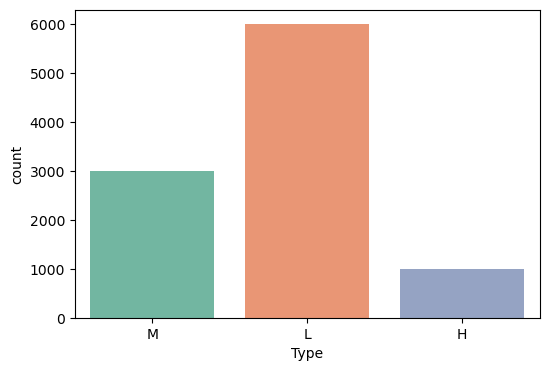

In [176]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Type', data = df, palette = 'Set2')
plt.show()

### Checking for count of differents Targets for Machine Failure

In [177]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

### Visualizing count for different Targets for Machine Failure

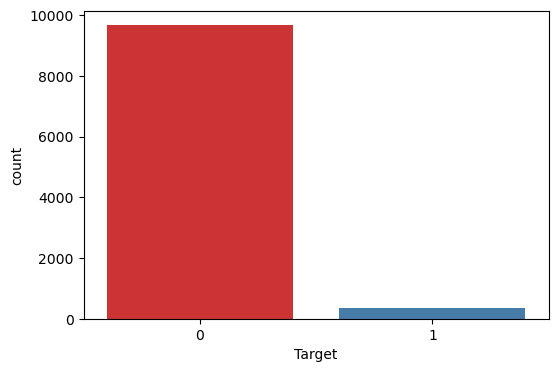

In [178]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Target', data = df, palette = 'Set1')
plt.show()

### Visualizing Correlation in the dataset

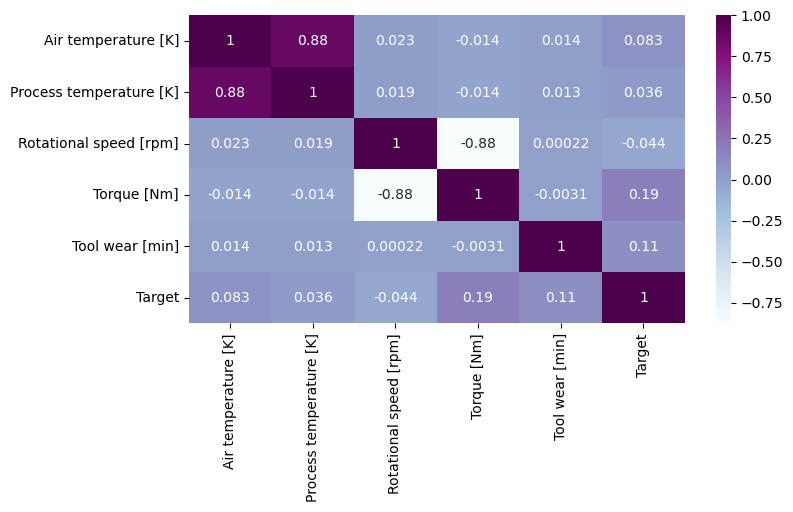

In [179]:
plt.figure(figsize = (8, 4))
numeric_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
heatmap_data = df[numeric_columns].corr()

sns.heatmap(heatmap_data, cmap = 'BuPu', annot = True)
plt.show()

### Visualizing The Average Torque (Nm) for different Failure Type

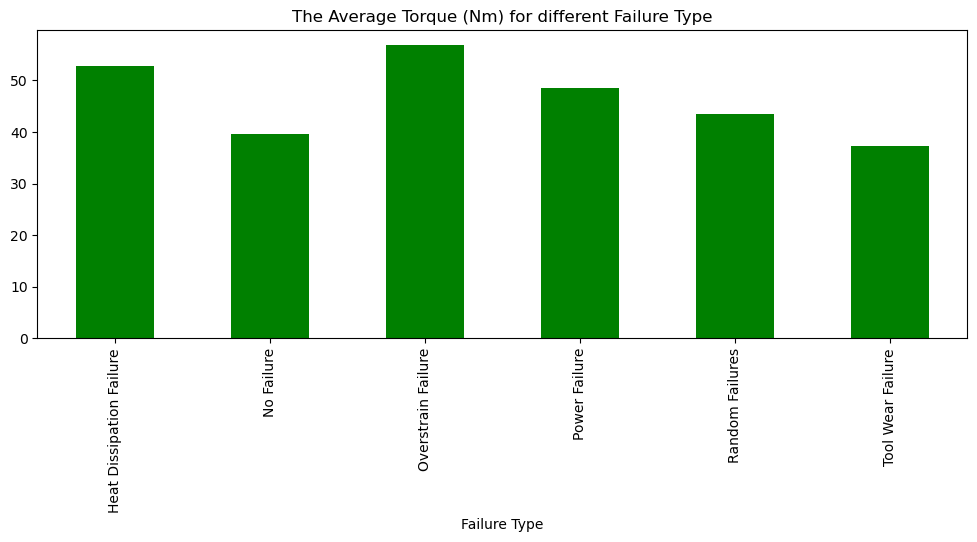

In [180]:
plt.figure(figsize = (12, 4))
df.groupby('Failure Type')['Torque [Nm]'].mean().plot(kind = 'bar', color = 'g')
plt.title("The Average Torque (Nm) for different Failure Type", fontsize = 12)
plt.show()

### Visualizing The Average Rotational Speed (rpm) for different Failure Type

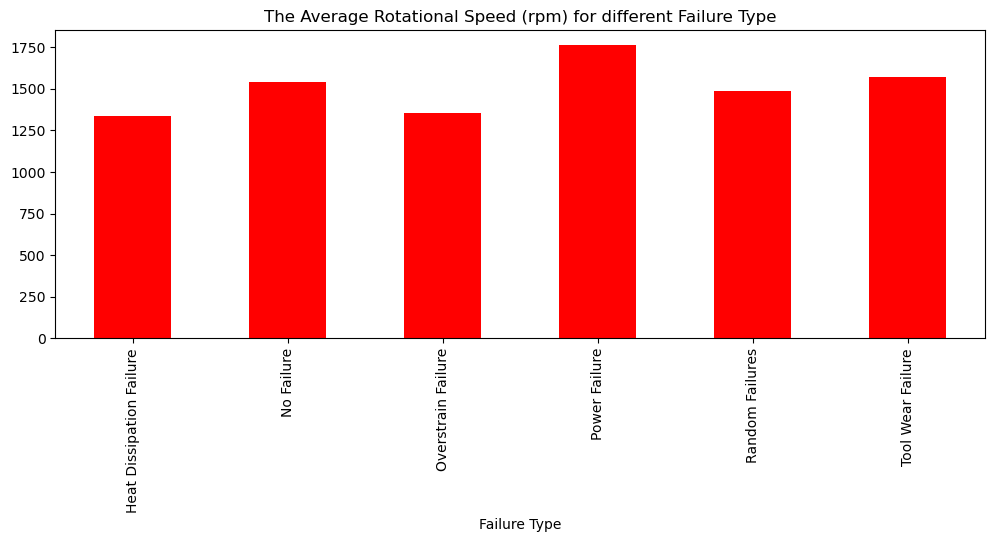

In [181]:
plt.figure(figsize = (12, 4))
df.groupby('Failure Type')['Rotational speed [rpm]'].mean().plot(kind = 'bar', color = 'r')
plt.title("The Average Rotational Speed (rpm) for different Failure Type", fontsize = 12)
plt.show()

### Visualizing The Average Process Temperature (K) for different Failure Type

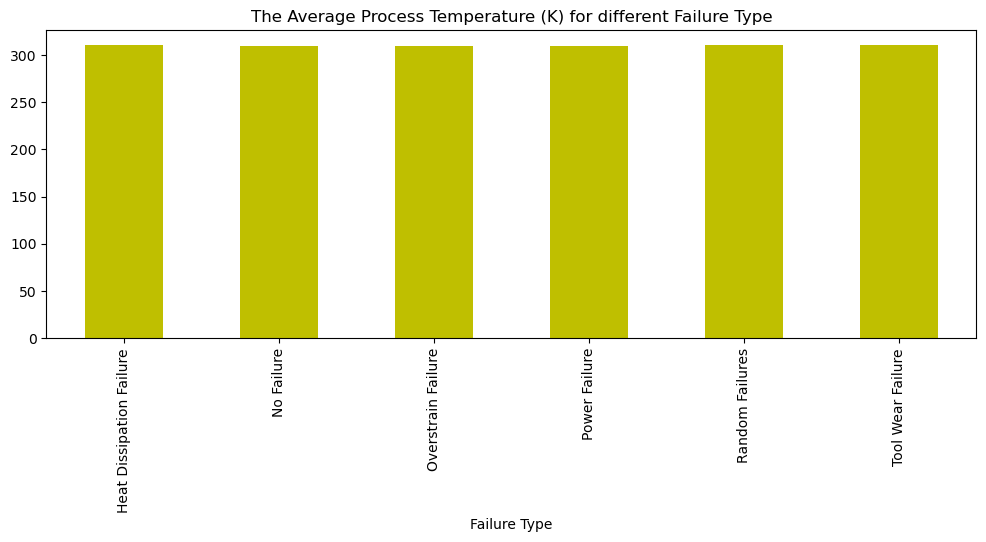

In [182]:
plt.figure(figsize = (12, 4))
df.groupby('Failure Type')['Process temperature [K]'].mean().plot(kind = 'bar', color = 'y')
plt.title("The Average Process Temperature (K) for different Failure Type", fontsize = 12)
plt.show()

### Visualizing The Average Air Temperature (K) for different Failure Type

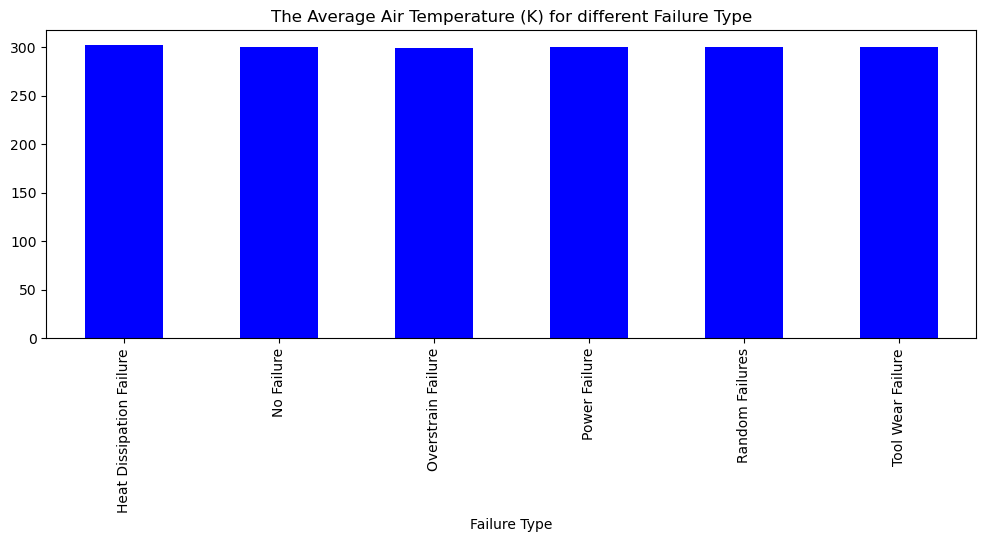

In [183]:
plt.figure(figsize = (12, 4))
df.groupby('Failure Type')['Air temperature [K]'].mean().plot(kind = 'bar', color = 'b')
plt.title("The Average Air Temperature (K) for different Failure Type", fontsize = 12)
plt.show()

### Replacing string value to numerical value in Type column

In [184]:
df['Type'] = df['Type'].replace({'L' : 0, 'M' : 1, 'H' : 2})

In [185]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M14860,1,298.1,308.6,1551,42.8,0,0,No Failure
1,L47181,0,298.2,308.7,1408,46.3,3,0,No Failure
2,L47182,0,298.1,308.5,1498,49.4,5,0,No Failure
3,L47183,0,298.2,308.6,1433,39.5,7,0,No Failure
4,L47184,0,298.2,308.7,1408,40.0,9,0,No Failure


### Replacing string value to numerical value in Failure Type column

In [186]:
df['Failure Type'] = df['Failure Type'].replace({'No Failure' : 0, 
                                                 'Heat Dissipation Failure' : 1, 
                                                 'Power Failure' : 2, 
                                                 'Overstrain Failure' : 3, 
                                                 'Tool Wear Failure' : 4, 
                                                 'Random Failures' : 5})

In [187]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M14860,1,298.1,308.6,1551,42.8,0,0,0
1,L47181,0,298.2,308.7,1408,46.3,3,0,0
2,L47182,0,298.1,308.5,1498,49.4,5,0,0
3,L47183,0,298.2,308.6,1433,39.5,7,0,0
4,L47184,0,298.2,308.7,1408,40.0,9,0,0


### Separating dependent & independent variable

In [188]:
x = df.iloc[:, 1:-1]
y = df['Failure Type']

### Distributing train & test samples for ML Algorithms

In [189]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

### Logistic Regression Model

In [201]:
log_reg_model = LogisticRegression(solver='lbfgs', max_iter=10000)
log_reg_model.fit(x_train, y_train)

y_log_reg_pred = log_reg_model.predict(x_test)

log_reg_accuracy = round(accuracy_score(y_log_reg_pred, y_test) * 100, 2)

print("Model Accuracy Score :",log_reg_accuracy ,"%")
print("Classification_Report: \n",classification_report(y_test,y_log_reg_pred))

Model Accuracy Score : 99.48 %
Classification_Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2424
           1       0.87      1.00      0.93        20
           2       0.95      0.87      0.91        23
           3       0.88      0.93      0.90        15
           4       0.92      0.92      0.92        12
           5       0.00      0.00      0.00         6

    accuracy                           0.99      2500
   macro avg       0.77      0.79      0.78      2500
weighted avg       0.99      0.99      0.99      2500



### Decision Tree Classifier Model

In [211]:
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)

y_decision_tree_pred = decision_tree_model.predict(x_test)

decision_tree_accuracy = round(accuracy_score(y_decision_tree_pred, y_test) * 100, 2)

print("Model Accuracy Score :",decision_tree_accuracy ,"%")
print("Classification_Report: \n",classification_report(y_test,y_decision_tree_pred))

Model Accuracy Score : 99.0 %
Classification_Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2424
           1       0.87      1.00      0.93        20
           2       0.94      0.70      0.80        23
           3       0.79      0.73      0.76        15
           4       0.92      0.92      0.92        12
           5       0.00      0.00      0.00         6

    accuracy                           0.99      2500
   macro avg       0.75      0.72      0.73      2500
weighted avg       0.99      0.99      0.99      2500



### Random Forest Classifier Model

In [215]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(x_train, y_train)
y_rf_pred = rf_model.predict(x_test)

rf_accuracy = round(accuracy_score(y_rf_pred, y_test) * 100, 2)

print("Model Accuracy Score :",rf_accuracy ,"%")
print("Classification_Report: \n",classification_report(y_test,y_rf_pred))

Model Accuracy Score : 99.6 %
Classification_Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2424
           1       0.95      1.00      0.98        20
           2       1.00      0.96      0.98        23
           3       0.87      0.87      0.87        15
           4       0.92      0.92      0.92        12
           5       0.00      0.00      0.00         6

    accuracy                           1.00      2500
   macro avg       0.79      0.79      0.79      2500
weighted avg       0.99      1.00      0.99      2500



### Support Vector Classifier Model

In [221]:
svc_model = SVC()
svc_model.fit(x_train, y_train)
y_svc_pred = svc_model.predict(x_test)

svc_accuracy = round(accuracy_score(y_svc_pred, y_test) * 100, 2)

print("Model Accuracy Score :",svc_accuracy ,"%")
print("Classification_Report: \n",classification_report(y_test,y_svc_pred))

Model Accuracy Score : 97.0 %
Classification_Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      2424
           1       0.00      0.00      0.00        20
           2       1.00      0.04      0.08        23
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        12
           5       0.00      0.00      0.00         6

    accuracy                           0.97      2500
   macro avg       0.33      0.17      0.18      2500
weighted avg       0.95      0.97      0.96      2500



### Creating a new DataFrame to visualize best ML Algorithm

In [223]:
models_df = pd.DataFrame({"Models": [ 'Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'Support Vector Classifier'],
                           "Accuracy": [log_reg_accuracy, decision_tree_accuracy, rf_accuracy, svc_accuracy]})

models_df.set_index('Models', inplace=True)
models_df.head()

,Accuracy
Models,
Logistic Regression,99.48
Decision Tree Classifier,99.00
Random Forest Classifier,99.60
Support Vector Classifier,97.00
